# Problem
- Target Variable (y): Final outcome (1 for Success, 0 for Failure).
- Input Features (X): Hours of study per week, Absence rate, Math grade average, French grade average, Class participation score.
- Task Type: Binary Classification, as the goal is to map the continuous and categorical input features to one of two discrete, mutually exclusive classes (Success or Failure).

In [4]:
# modules and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay
print("Imported")

Imported


In [9]:
import pandas as pd
import numpy as np

# set random seed for reproducibility
np.random.seed(42)

# students number
n_students = 100

# generate base features
# study hours (normal distribution around 15 hours, some intentional negative typos)
study_hours = np.random.normal(loc=15, scale=5, size=n_students)
study_hours[10] = -2.5  # Intentional negative value for testing
study_hours[42] = -5.0  # Intentional negative value for testing

# absences (Poisson distribution, mostly 0-5 absences, some negative typos)
absences = np.random.poisson(lam=3, size=n_students)
absences[15] = -1  # Intentional negative value
absences[99] = -3  # Intentional negative value

# Math and French grades (0 to 20 French scale)
math_grades = np.random.normal(loc=12, scale=3, size=n_students)
french_grades = np.random.normal(loc=11, scale=3, size=n_students)

# Clip grades to ensure they stay strictly within 0-20 bounds
math_grades = np.clip(math_grades, 0, 20)
french_grades = np.clip(french_grades, 0, 20)

# Participation score (0 to 10)
participation = np.random.randint(0, 11, size=n_students)

# 2. Determine Final Outcome (Success/Failure)
# We create a hidden "success score" to make the classification realistic.
# Higher grades, higher participation, more study, and fewer absences = better chance of success.
success_probability = (
    (study_hours * 0.5) - 
    (absences * 1.2) + 
    (math_grades * 2.0) + 
    (french_grades * 1.5) + 
    (participation * 1.0)
)

# Normalize probabilities roughly between 0 and 1, then convert to 1 (Pass) or 0 (Fail)
# We use the median as a threshold to get roughly 50% pass rate
threshold = np.median(success_probability)
final_outcome = (success_probability >= threshold).astype(int)

df = pd.DataFrame({
    'Hours of study per week': np.round(study_hours, 1),
    'Absence rate': absences,
    'Math grade average': np.round(math_grades, 1),
    'French grade average': np.round(french_grades, 1),
    'Class participation score': participation,
    'Final outcome': final_outcome
})

df.to_csv('/home/rohitsolanki/programs/jupyter/data/StudentSuccess.csv', index=False)
print("StudentSuccess.csv successfully created with 100 rows!")
display(df.head(15))

StudentSuccess.csv successfully created with 100 rows!


,Hours of study per week,Absence rate,Math grade average,French grade average,Class participation score,Final outcome
0,17.5,2,7.9,11.1,3,0
1,14.3,4,13.6,11.4,9,1
2,18.2,4,15.2,9.9,10,1
3,22.6,2,16.6,10.3,10,1
4,13.8,2,9.5,9.6,4,0
5,13.8,3,11.1,9.1,3,0
6,22.9,5,12.7,9.9,10,1
7,18.8,5,18.1,9.8,9,1
8,12.7,3,12.3,8.5,7,0
9,17.7,2,16.7,9.4,5,1


In [7]:
import os
print("Jupyter is currently running in:", os.getcwd())
print("Files/folders here:", os.listdir())

Jupyter is currently running in: /home/rohitsolanki/programs/jupyter
Files/folders here: ['.git', 'outputs', '.ipynb_checkpoints', '.venv', 'notebooks', 'README.md', '.gitignore', 'data', 'requirements.txt']


In [12]:
df = df.clip(lower=0)

# Problem Formulation
# target: Final outcome (0 or 1)
# features: Study hours, Absences, Math grade, French grade, Participation
X = df[['Hours of study per week', 'Absence rate', 'Math grade average', 
        'French grade average', 'Class participation score']]
y = df['Final outcome']

In [13]:
# split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features to mean=0 and variance=1 (Critical for k-NN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Create an empty list to store the scores for each model
results_list = []

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Generate the report as a dictionary
    report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
    
    # Extract the metrics we care about and add them to our list
    results_list.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })

output_df = pd.DataFrame(results_list)

display(output_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,LogReg,1.00,1.000000,1.00,1.000000
1,kNearest,0.95,0.954545,0.95,0.949875
2,DecisionTree,0.95,0.954545,0.95,0.949875
3,SVM,0.90,0.916667,0.90,0.898990


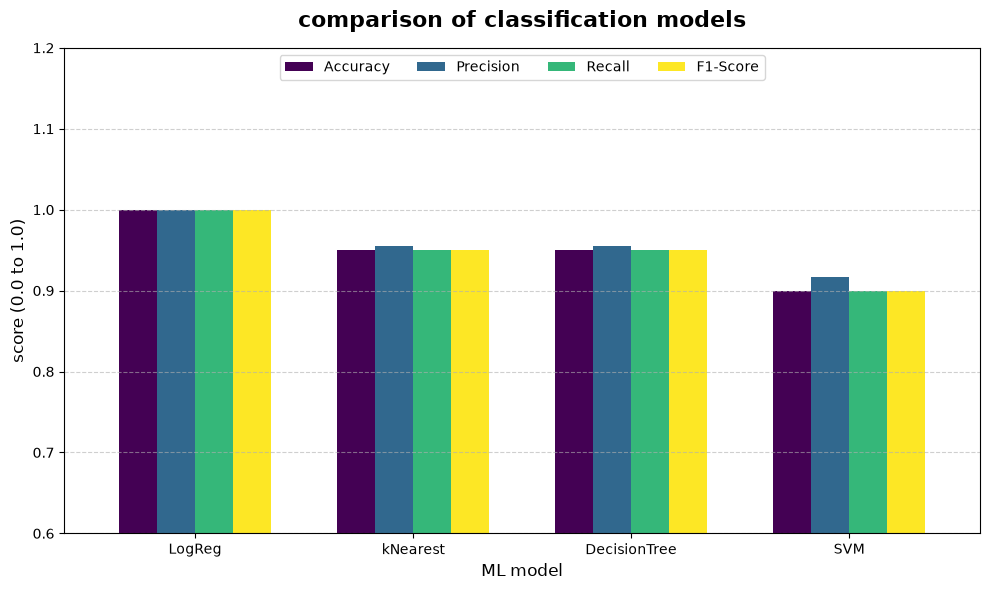

In [21]:
# set the 'Model' column as the index so it acts as our X-axis labels
plot_df = output_df.set_index('Model')

# create a grouped bar chart
ax = plot_df.plot(kind='bar', figsize=(10, 6), colormap='viridis', width=0.7)

# format the plot for readability
plt.title('comparison of classification models', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('ML model', fontsize=12)
plt.ylabel('score (0.0 to 1.0)', fontsize=12)

# set y-axis limit a bit above 1.0 to leave room for the legend
plt.ylim(0.6, 1.2) 
plt.xticks(rotation=0) 
plt.legend(loc='upper center', ncol=4) 
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

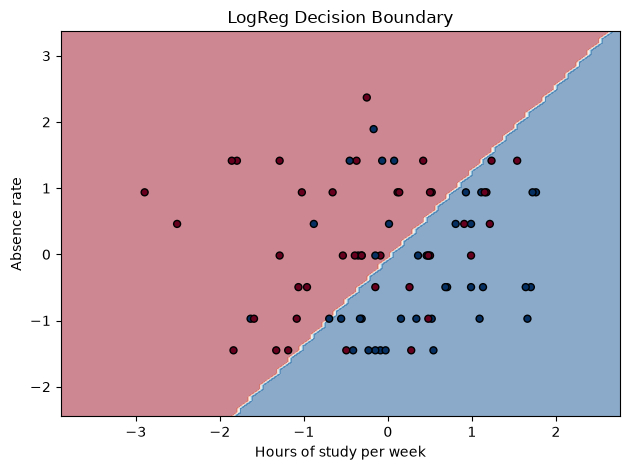

<Figure size 600x500 with 0 Axes>

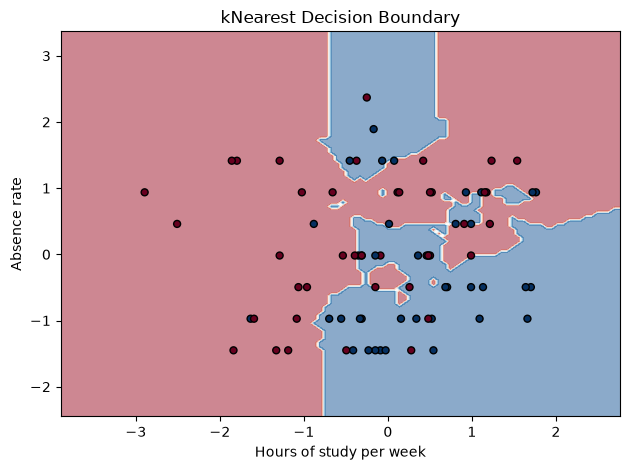

<Figure size 600x500 with 0 Axes>

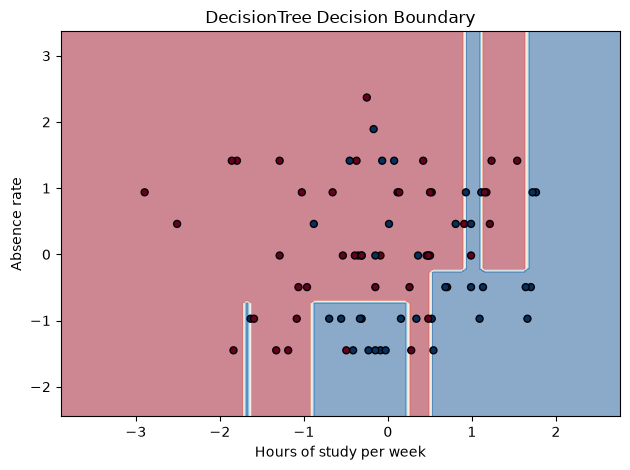

<Figure size 600x500 with 0 Axes>

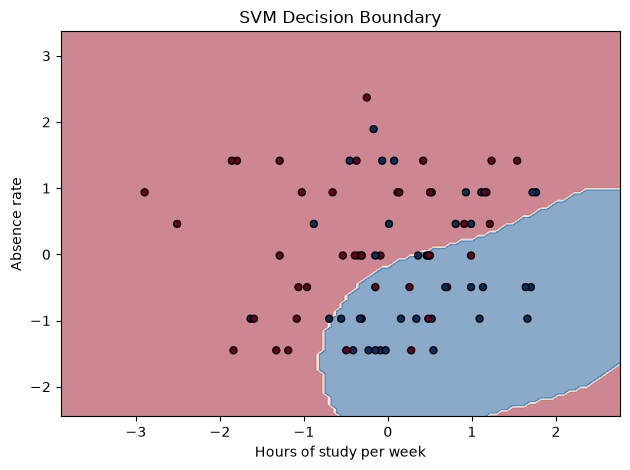

In [34]:
# Loop through and create a completely separate plot for each model
for name, model in models.items():
    # 1. Create a new, separate figure
    plt.figure(figsize=(6, 5))
    
    # 2. Retrain model on just the 2 selected features
    model.fit(X_train_2d_scaled, y_train)
    
    # 3. Plot the background decision regions
    # (By removing the 'ax=' argument, it automatically uses the new figure)
    DecisionBoundaryDisplay.from_estimator(
        model, X_train_2d_scaled, response_method="predict", 
        cmap=plt.cm.RdBu, alpha=0.5, 
        xlabel=features_2d[0], ylabel=features_2d[1]
    )
    
    # overlay the actual training data points, blue = pass
    scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1], 
                          c=y_train, cmap=plt.cm.RdBu, edgecolors='black', s=25)
    
    # 5. Add title and the simple legend we discussed earlier
    plt.title(f"{name} Decision Boundary")
    # 6. Display this specific plot, then close it to make room for the next one
    plt.tight_layout()
    plt.show()
    plt.close()